# Part 2 (a)

Import the necessary and essential Python packages for our data analysis: Pandas, SQLite3, Matplotlib, Seaborn and os.

The "pandas" library is a data manipulation and analysis library that provides data structures and functions required to perform data analysis.

The "sqlite3" modeule is a lightweight database engine that allows interactions with SQLite databases for us to store and query for data.

The "pyplot" module from the "matplotlib" library is a plotting library to create visualisations that we need below.

The "seaborn" library is a interface that draws informative statistical graphs.

The "os" module provides a way to interact with the operating system for file path manipulations or checking for the existence of certain files.

In [1]:
#Import necessary packages

import pandas as pd

import sqlite3

import matplotlib.pyplot as plt

import seaborn as sns

import os

Check for the existence of SQLite database file "flight_data.db" in our current directory. If it exists, we remove the file. This is to ensure that we do not have any overwriting existing data when running the codes later.

In [2]:
#Check if the database file exists

if os.path.exists("flight_data.db"):

    os.remove("flight_data.db")

Create an SQLite database 'flight_data.db' to store flight data. Then, we use the code below to check for the connection status.

In [3]:
#Creation of database

conn = sqlite3.connect("flight_data.db")

#Check the connection

if conn is not None:
    print("Connection successful.")
else:
    print("Connection failed.")

Connection successful.


"os.chdir()" is a function from the "os" module that helps us to change the current working directory to the specified path, "/Users/joline/Desktop/prog me". 

In [4]:
#Set working directory

os.chdir("/Users/joline/Desktop/prog me")

### Write data to flight data database

Load the necessary data from 3 CSV files ("airports.csv", "carriers.csv" and "plane_data.csv") into pandas dataframes (airports_df, carriers_df and planes_df) using "pd.read_csv()", then store into SQLite database using "to_sql()".

This is done for the necessary data to be easily accessed and queried for in our analysis later.

In [5]:
#Load data from airports, carriers, & plane data CSV files

airports_df = pd.read_csv("airports.csv")
carriers_df = pd.read_csv("carriers.csv")
planes_df = pd.read_csv("plane_data.csv")

airports_df.to_sql("airports", conn, index=False)
carriers_df.to_sql("carriers", conn, index=False)
planes_df.to_sql("planes", conn, index=False)

5029

In this dataset from the Harvard Dataverse, it consists of flight details for carriers within the USA ranging from October 1987 to April 2008.

For this analysis, I have chosen to work with a subset of ten consecutive years from 1994 to 2003.

First, we set up a loop that iterates over the 10 years from 1994 to 2003. Within this loop, we read the CSV files corresponding to the current year, "i", using the pandas "read_csv()" function. After reading the CSV files into our pandas data frame, "ontime_df_temporary", we save the data frmae into a SQLite database table, "ontime", using "sql()". 

This is done to store the data from the 10 years from 1994 to 2003 to be stored into just one database table for further analysis.

In [6]:
#Load CSV files from 1994 to 2003 into ontime table

for i in range(1994, 2004):
    ontime_df_temporary = pd.read_csv(f"{i}.csv.bz2", encoding = 'latin1')
    ontime_df_temporary.to_sql("ontime", conn, index=False, if_exists="append")

/var/folders/7z/t8_72tg147b372z_pt1btyvr0000gn/T/ipykernel_27448/1802759672.py:4: DtypeWarning: Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.
  ontime_df_temporary = pd.read_csv(f"{i}.csv.bz2", encoding = 'latin1')


We want to check the necessary years of data have been stored into the "ontime" table of the SQLite database.

Use "pd.read_sql_query()" from pandas to execute an SQL query against the SQLite database connected via "conn". This SQL query selects distinct values from the "Year" column from the "ontime" table. The result of this query is stored in a pandas data frame named "unique_years". 

In [7]:
#SQL query to check unique years from ontime table

unique_years = pd.read_sql_query("SELECT DISTINCT Year FROM ontime", conn)

#Print unique years

print(unique_years)

   Year
0  1994
1  1995
2  1996
3  1997
4  1998
5  1999
6  2000
7  2001
8  2002
9  2003


## General Background Data (i)

**Queries via DBI**

**SQL query to calculate the percentages of cancelled flights and average arrival delay by month of year**

We will conduct SQL queries against the SQLite database via DBI to gather relevant insights of flight performance metrics such as flight cancellation rates, flight diversion rates and average arrival delay for further analysis.

This query calculates the percentage of cancelled flights, diverted flights and delayed flights for each month.

"AVG(Cancelled) * 100" is used to calculate the average percentage of cancelled flights.
"AVG(Diverted) * 100" is used to calculate the average percentage of diverted flights.
"(CAST(SUM(CASE WHEN ArrDelay > 0 THEN 1 ELSE 0 END) AS FLOAT)/CAST(COUNT ( * ) AS FLOAT)) * 100" is used to calculate the percentage of delayed flights by counting the number of flights with arrival delay more than 0, then dividing it by the total number of flights and multiplying by 100. 
The results are then grouped by and ordered by month.

In [8]:
#Query to calculate percentage of cancelled, diverted, and delayed flights by month

best_month_of_year = pd.read_sql_query("""
SELECT Month, AVG(Cancelled)*100 AS "% of Cancelled Flights",
    AVG(Diverted)*100 AS "% of Diverted Flights",
    (CAST(SUM(CASE WHEN ArrDelay > 0 THEN 1 ELSE 0 END) AS FLOAT)/CAST(COUNT(*) AS FLOAT))*100 AS "% of Delayed Flights"
FROM ontime
GROUP BY Month
ORDER BY Month
""", conn)

In [9]:
#Print results

print(best_month_of_year)

    Month  % of Cancelled Flights  % of Diverted Flights  % of Delayed Flights
0       1                3.903435               0.286109             47.885419
1       2                3.075382               0.240235             46.783504
2       3                2.014682               0.195275             46.280163
3       4                1.542368               0.186161             44.634628
4       5                1.624892               0.188431             43.942778
5       6                2.041928               0.289812             49.696189
6       7                1.915837               0.258751             47.550914
7       8                1.943339               0.245667             46.964842
8       9                4.167995               0.170188             38.583836
9      10                1.431987               0.161694             43.372250
10     11                1.480177               0.178483             44.588234
11     12                2.331003               0.23

This query calculates the average arrival delay for each month, considering only non-cancelled and non-diverted flights.

"AVG(ArrDelay)" is used to calculate the average arrival delay in minutes.
The results are then grouped by and ordered by month.

In [10]:
#Query to calculate average arrival delay by month

average_arrival_delay = pd.read_sql_query("""
SELECT Month, AVG(ArrDelay) AS "Average Arrival Delay (mins)"
FROM ontime
WHERE Cancelled = 0 AND Diverted = 0
GROUP BY Month
ORDER BY Month
""", conn)

In [11]:
#Print results

print(average_arrival_delay)

    Month  Average Arrival Delay (mins)
0       1                      8.622142
1       2                      7.242708
2       3                      6.441578
3       4                      5.609618
4       5                      5.500201
5       6                      9.742919
6       7                      8.506477
7       8                      7.792821
8       9                      3.191118
9      10                      4.297232
10     11                      5.073683
11     12                      9.307026


**Data Visualisation: Bar plot for percentage of delayed flights against month**

We want to generate a bar plot to visualise the percentage of delayed flights by month, using seaborn "sns".

The "x" parameter specifies the column from the data frame, "best_month_of_year" to be plotted on the x-axis, which is 'Month'. 
The "y" parameter specifies the column representing the percentage of delayed flights, which is '% of Delayed Flights'. The "data" parameter specifies the data frame containing the results to be plotted, which is "best_month_of_year".

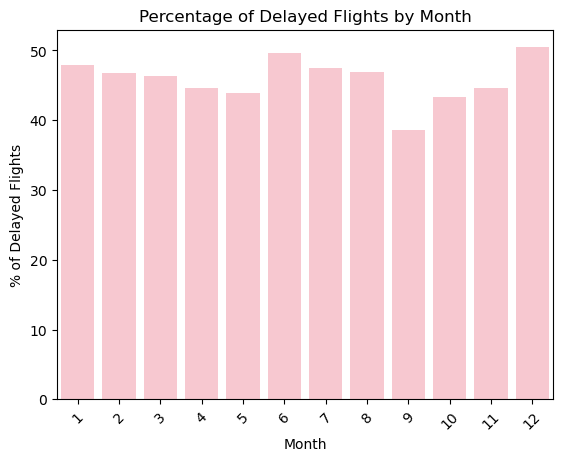

In [12]:
sns.barplot(x='Month', y='% of Delayed Flights', data=best_month_of_year, color = 'pink')

plt.title('Percentage of Delayed Flights by Month')

plt.xticks(rotation=45)

plt.show()

From the query above, these are the analysis for the 10 years from 1994 to 2003 in general:

September has the highest percentage of cancelled flights (4.2%), while October has the lowest percentage of cancelled flights (1.4%).

June has the highest percentage of diverted flights (0.3%), while October has the lowest percentage of cancelled flights (0.1%).

December has the highest percentage of delayed flights (50.5%), while September has the lowest percentage of delayed flights (38.6%).

**Data Visualisation: Bar plot for average arrival delay in minutes against month**

We want to generate a bar plot to visualise the average arrival delay in minutes by day of the week, using seaborn "sns".

The "x" parameter specifies the column from the data frame, "average_arrival_delay" to be plotted on the x-axis, which is 'Month'.
The "y" parameter specifies the column representing the percentage of delayed flights, which is '% of Delayed Flights'.
The "data" parameter specifies the data frame containing the results to be plotted, which is "average_arrival_delay".

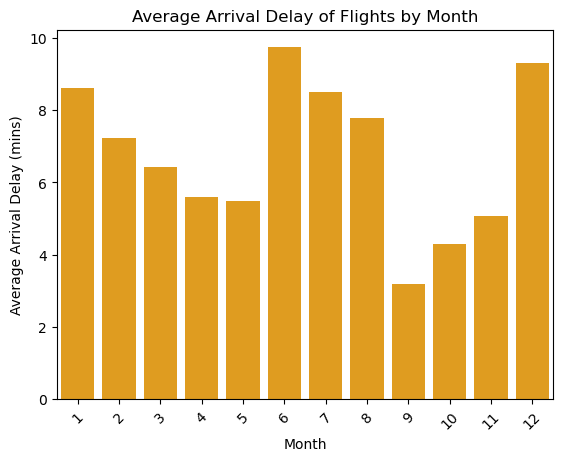

In [13]:
sns.barplot(x='Month', y='Average Arrival Delay (mins)', data=average_arrival_delay, color = 'orange')

plt.title('Average Arrival Delay of Flights by Month')

plt.xticks(rotation=45)

plt.show()

From the query above, this is the analysis for the 10 years from 1994 to 2003 in general:

June has the highest average arrival delay (9.7 mins), while September has the lowest average arrival delay (3.2 mins).

## General Background Data (ii)

**Queries via DBI**

**SQL query to calculate the percentages of cancelled flights and average arrival delay by the day of week**

We will conduct SQL queries against the SQLite database via DBI to gather relevant insights of flight performance metrics such as flight cancellation rates, flight diversion rates and average arrival delay for further analysis.

This query calculates the percentage of cancelled flights, diverted flights and delayed flights for each day of the week.

"AVG(Cancelled) * 100" is used to calculate the average percentage of cancelled flights. "AVG(Diverted) * 100" is used to calculate the average percentage of diverted flights. "(CAST(SUM(CASE WHEN ArrDelay > 0 THEN 1 ELSE 0 END) AS FLOAT)/CAST(COUNT ( * ) AS FLOAT)) * 100" is used to calculate the percentage of delayed flights by counting the number of flights with arrival delay more than 0, then dividing it by the total number of flights and multiplying by 100. The results are then grouped by and ordered by day of week.

In [14]:
#Query to calculate percentage of cancelled, diverted and delayed flights by day of week

best_day_of_week = pd.read_sql_query("""
SELECT DayOfWeek, AVG(Cancelled)*100 AS "% of Cancelled Flights",
    AVG(Diverted)*100 AS "% of Diverted Flights",
    (CAST(SUM(CASE WHEN ArrDelay > 0 THEN 1 ELSE 0 END) AS FLOAT)/CAST(COUNT(*) AS FLOAT))*100 AS "% of Delayed Flights"
FROM ontime
GROUP BY DayOfWeek
ORDER BY DayOfWeek
""", conn)

In [15]:
#Print results

print(best_day_of_week)

   DayOfWeek  % of Cancelled Flights  % of Diverted Flights  \
0          1                2.342626               0.220480   
1          2                2.685367               0.215884   
2          3                2.574061               0.219514   
3          4                2.468304               0.228639   
4          5                2.244341               0.233759   
5          6                1.946095               0.211252   
6          7                1.645744               0.210355   

   % of Delayed Flights  
0             44.666157  
1             43.647503  
2             45.921940  
3             49.500285  
4             50.885029  
5             40.805730  
6             45.363859  


This query calculates the average arrival delay for each day of the week, considering only non-cancelled and non-diverted flights.

"AVG(ArrDelay)" is used to calculate the average arrival delay in minutes. The results are then grouped by and ordered by day of the week.

In [16]:
#Query to calculate average arrival delay by day of week

average_arrival_delay2 = pd.read_sql_query("""
SELECT DayOfWeek, AVG(ArrDelay) AS "Average Arrival Delay (mins)"
FROM ontime
WHERE Cancelled = 0 AND Diverted = 0
GROUP BY DayOfWeek
ORDER BY DayOfWeek
""", conn)

In [17]:
#Print results

print(average_arrival_delay2)

   DayOfWeek  Average Arrival Delay (mins)
0          1                      6.211056
1          2                      5.524317
2          3                      6.755763
3          4                      8.699091
4          5                      9.642754
5          6                      4.004494
6          7                      6.383592


**Data Visualisation: Bar plot for percentage of delayed flights against the day of week**

We want to generate a bar plot to visualise the percentage of delayed flights by day of the week, using seaborn "sns".

The "x" parameter specifies the column from the data frame, "best_day_of_week" to be plotted on the x-axis, which is 'DayOfWeek'.
The "y" parameter specifies the column representing the percentage of delayed flights, which is '% of Delayed Flights'.
The "data" parameter specifies the data frame containing the results to be plotted, which is "best_day_of_week".

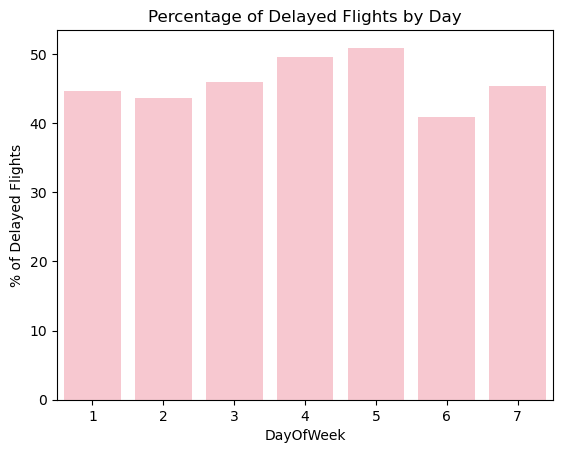

In [18]:
sns.barplot(x='DayOfWeek', y='% of Delayed Flights', data=best_day_of_week, color = 'pink')

plt.title('Percentage of Delayed Flights by Day')

plt.show()

From the query above, these are the analysis for the 10 years from 1994 to 2003 in general:

Tuesday has the highest percentage of cancelled flights (2.7%), while Sunday has the lowest percentage of cancelled flights (1.6%).

Friday has the highest percentage of diverted flights (0.2%), while Sunday has the lowest percentage of cancelled flights (0.2%).

Friday has the highest percentage of delayed flights (50.9%), while Saturday has the lowest percentage of delayed flights (40.8%).

**Data Visualisation: Bar plot for average arrival delay in minutes against the day of week**

We want to generate a bar plot to visualise the average arrival delay in minutes by day of the week, using seaborn "sns".

The "x" parameter specifies the column from the data frame, "average_arrival_delay2" to be plotted on the x-axis, which is 'DayOfWeek'.
The "y" parameter specifies the column representing the percentage of delayed flights, which is '% of Delayed Flights'.
The "data" parameter specifies the data frame containing the results to be plotted, which is "average_arrival_delay2".

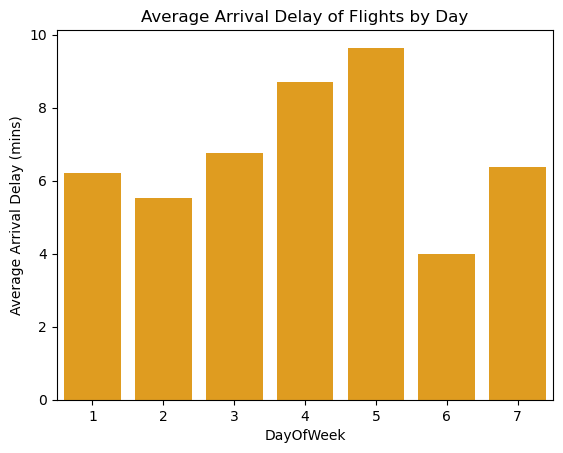

In [19]:
sns.barplot(x='DayOfWeek', y='Average Arrival Delay (mins)', data=average_arrival_delay2, color = 'orange')

plt.title('Average Arrival Delay of Flights by Day')

plt.show()

From the query above, this is the analysis for the 10 years from 1994 to 2003 in general:

Friday has the highest average arrival delay (9.6 mins), while Saturday has the lowest average arrival delay (4.0 mins).

## General Background Data (iii)

**Queries via DBI**

**SQL query to calculate percentage of cancelled flights and average arrival delay by time interval**

We will conduct SQL queries against the SQLite database via DBI to gather relevant insights of flight performance metrics such as flight cancellation rates, flight diversion rates and average arrival delay for further analysis.

This query calculates the percentage of cancelled flights, diverted flights and delayed flights for each time interval of the day.

"AVG(Cancelled) * 100" is used to calculate the average percentage of cancelled flights. "AVG(Diverted) * 100" is used to calculate the average percentage of diverted flights. "(CAST(SUM(CASE WHEN ArrDelay > 0 THEN 1 ELSE 0 END) AS FLOAT)/CAST(COUNT ( * ) AS FLOAT)) * 100" is used to calculate the percentage of delayed flights by counting the number of flights with arrival delay more than 0, then dividing it by the total number of flights and multiplying by 100. The results are then grouped by and ordered by time interval.

In [20]:
#Query to calculate percentage of cancelled, diverted and delayed flights by time interval

AirTime = pd.read_sql_query("""
SELECT AVG(AirTime) AS Avg_Flight_Travel_Time
FROM ontime
WHERE Cancelled = 0
""", conn)

In [21]:
#Print results

print(AirTime)

   Avg_Flight_Travel_Time
0              102.925109


This query calculates the average arrival delay for each time interval, considering only non-cancelled and non-diverted flights.

"AVG(ArrDelay)" is used to calculate the average arrival delay in minutes. The results are then grouped by and ordered by time interval.

In [22]:
#Query to calculate average arrival delay by time interval

best_time_of_day = pd.read_sql_query("""
SELECT AVG(Cancelled)*100 AS "% of Cancelled Flights",
    AVG(Diverted)*100 AS "% of Diverted Flights",
    (CAST(SUM(CASE WHEN ArrDelay > 0 THEN 1 ELSE 0 END) AS FLOAT)/CAST(COUNT(*) AS FLOAT))*100 AS "% of Delayed Flights",
    CASE WHEN CRSDepTime BETWEEN 0 AND 159 THEN '0000 to 0159'
         WHEN CRSDepTime BETWEEN 200 AND 359 THEN '0200 to 0359'
         WHEN CRSDepTime BETWEEN 400 AND 559 THEN '0400 to 0559'
         WHEN CRSDepTime BETWEEN 600 AND 759 THEN '0600 to 0759'
         WHEN CRSDepTime BETWEEN 800 AND 959 THEN '0800 to 0959'
         WHEN CRSDepTime BETWEEN 1000 AND 1159 THEN '1000 to 1159'
         WHEN CRSDepTime BETWEEN 1200 AND 1359 THEN '1200 to 1359'
         WHEN CRSDepTime BETWEEN 1400 AND 1559 THEN '1400 to 1559'
         WHEN CRSDepTime BETWEEN 1600 AND 1759 THEN '1600 to 1759'
         WHEN CRSDepTime BETWEEN 1800 AND 1959 THEN '1800 to 1959'
         WHEN CRSDepTime BETWEEN 2000 AND 2159 THEN '2000 to 2159'
         WHEN CRSDepTime BETWEEN 2200 AND 2359 THEN '2200 to 2359'
    END AS TimeFrame
FROM ontime
GROUP BY TimeFrame
ORDER BY TimeFrame
""", conn)

In [23]:
#Print results

print(best_time_of_day)

    % of Cancelled Flights  % of Diverted Flights  % of Delayed Flights  \
0                 0.465116               0.465116             49.767442   
1                 2.945565               0.265359             46.348747   
2                 1.432702               0.202822             37.832823   
3                 2.658865               0.185676             32.903518   
4                 2.204170               0.233857             37.451214   
5                 2.129651               0.192687             41.748475   
6                 2.343260               0.182855             43.919131   
7                 2.228906               0.227022             45.879570   
8                 2.318485               0.231617             48.555803   
9                 2.465845               0.243328             50.750303   
10                2.395897               0.232185             51.349941   
11                2.141648               0.202891             50.127926   
12                1.80282

**Data Visualisation: Bar plot for percentage of delayed flights against the time of day**

We want to generate a bar plot to visualise the percentage of delayed flights by time of the day, using seaborn "sns".

The "x" parameter specifies the column from the data frame, "best_time_of_day" to be plotted on the x-axis, which is 'TimeFrmae'. The "y" parameter specifies the column representing the percentage of delayed flights, which is '% of Delayed Flights'. The "data" parameter specifies the data frame containing the results to be plotted, which is "best_time_of_day".

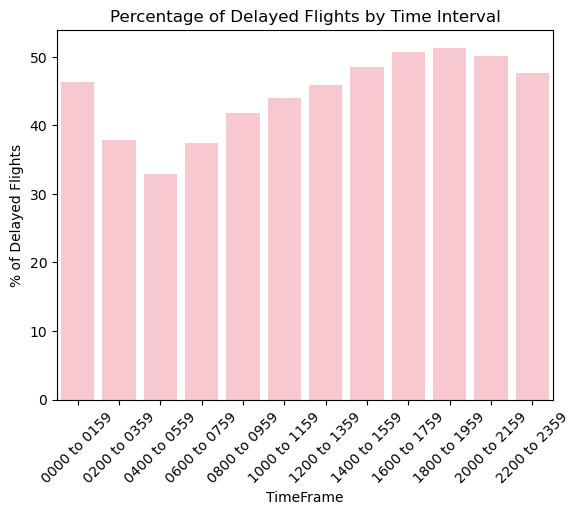

In [24]:
sns.barplot(x='TimeFrame', y='% of Delayed Flights', data=best_time_of_day, color = 'pink')

plt.title('Percentage of Delayed Flights by Time Interval')

plt.xticks(rotation=45)

plt.show()

From the query above, these are the analysis for the 10 years from 1994 to 2003 in general:

"0400 to 0559" has the highest percentage of cancelled flights (2.7%), while "0000 to 0159" has the lowest percentage of cancelled flights (0.5%).

"0000 to 0159" has the highest percentage of diverted flights (0.5%), while "0800 to 0959" has the lowest percentage of cancelled flights (0.2%).

"1800 to 1959" has the highest percentage of delayed flights (51.3%), while "0400 to 0559" has the lowest percentage of delayed flights (32.9%).

# Part 2(a) - Best Times to Minimise Delays Each Year

We want to generate a series of 10 bar plots, each showing the average arrival delay by the time of day (morning, afternoon, evening and night) for each year from 1994 to 2003 then visualising the best times to minimise delays over the years.

First, we iterate the codes over the 10 years from 1994 to 2003 and execute an SQL query to calculate the average arrival delay and departure delay in minutes grouped by the time of day for each year respectively. We filter our the cancelled and diverted flights for each year to only query for delayed flights. The results are then stored in the data frame "best_timeframe". 

Then, we use "barplot" from seaborn to create bar plots, where "x" represents the time of day and "y" represents the average arrival delay in minutes.

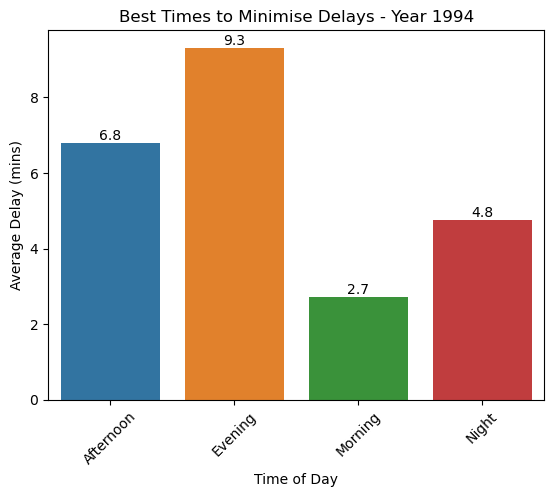

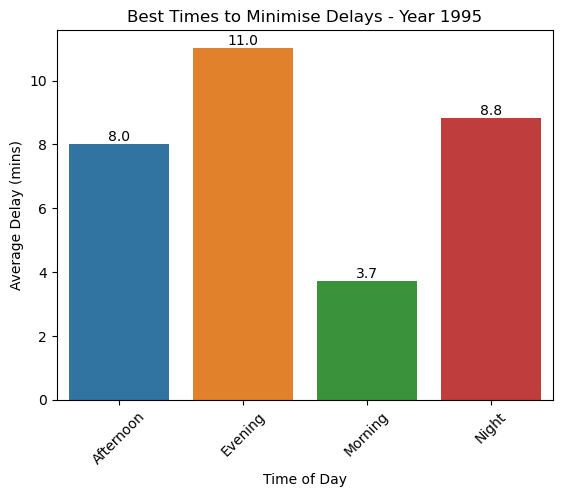

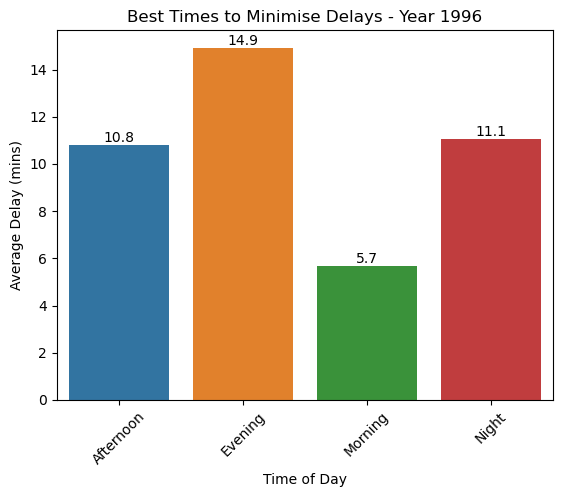

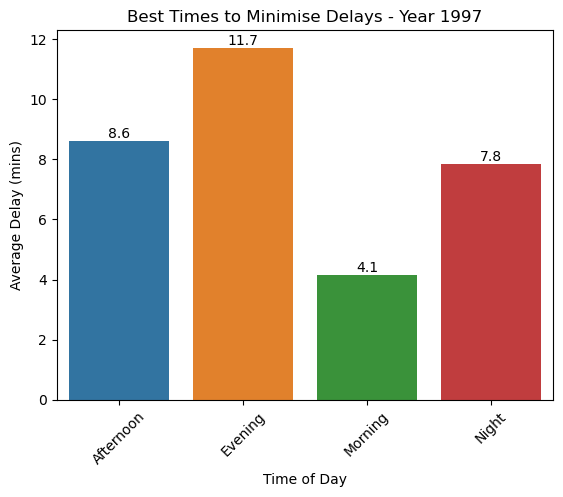

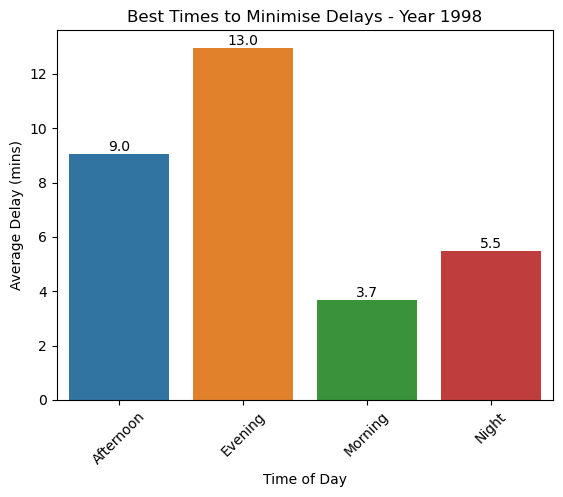

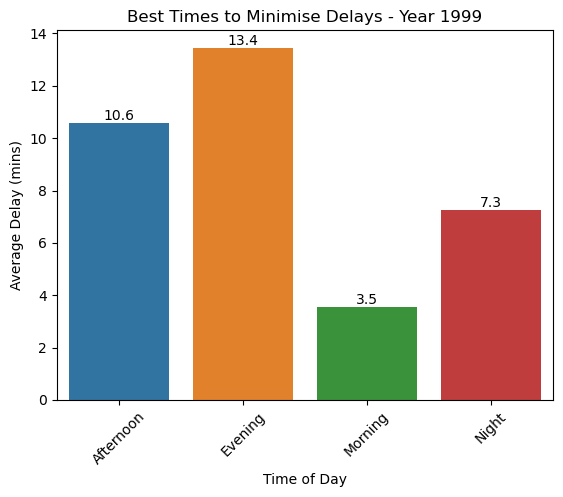

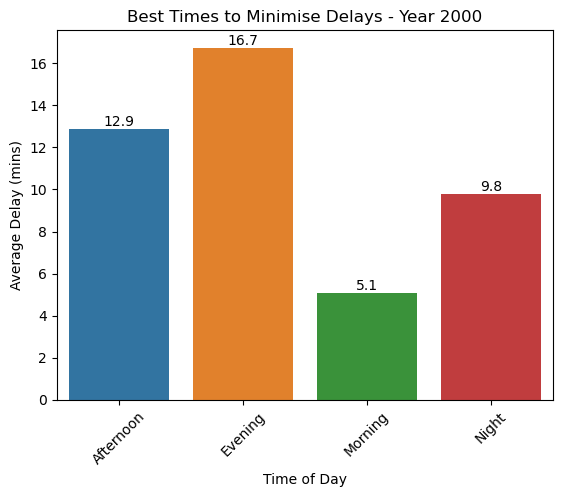

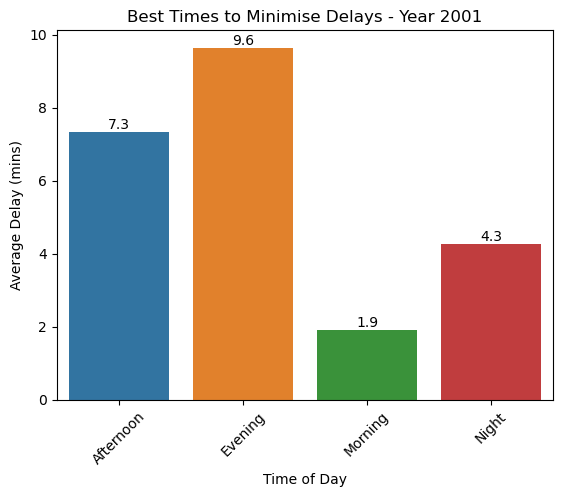

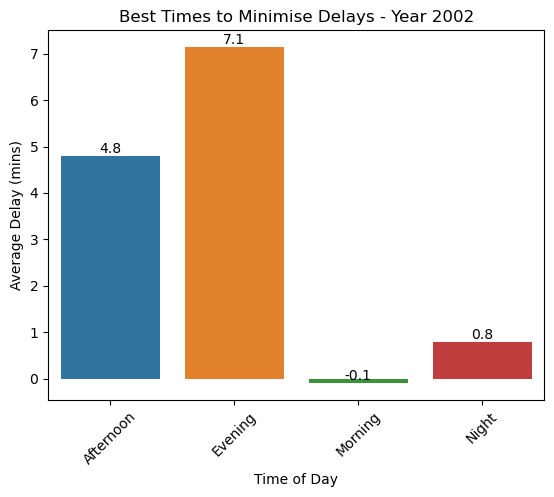

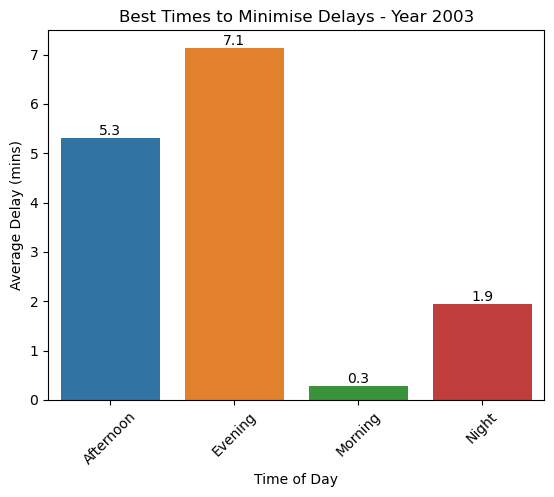

In [26]:
#Query for average arrival delay and departure delay grouped by time of day for each year

for year in range(1994, 2004):
    best_timeframe = pd.read_sql_query(f"""
    SELECT AVG(ArrDelay) AS Avg_ArrDelay, AVG(DepDelay) AS Avg_DepDelay,
           CASE WHEN CRSDepTime BETWEEN 600 AND 1159 THEN 'Morning'
                WHEN CRSDepTime BETWEEN 1200 AND 1759 THEN 'Afternoon'
                WHEN CRSDepTime BETWEEN 1800 AND 2159 THEN 'Evening'
                ELSE 'Night' END AS TimeOfDay
    FROM ontime
    WHERE Cancelled = 0 AND Diverted = 0 AND Year = {year}
    GROUP BY CASE WHEN CRSDepTime BETWEEN 600 AND 1159 THEN 'Morning'
                  WHEN CRSDepTime BETWEEN 1200 AND 1759 THEN 'Afternoon'
                  WHEN CRSDepTime BETWEEN 1800 AND 2159 THEN 'Evening'
                  ELSE 'Night' END
    ORDER BY TimeOfDay
    """, conn)
    
    #Rename columns
    
    best_timeframe.rename(columns={'Avg_ArrDelay': 'Average Arrival Delay (mins)', 'Avg_DepDelay': 'Average Departure Delay (mins)'}, inplace=True)
    
    #Data visualisation
    
    sns.barplot(x='TimeOfDay', y='Average Arrival Delay (mins)', data=best_timeframe)
    plt.title(f'Best Times to Minimise Delays - Year {year}')
    plt.xticks(rotation=45)
    plt.xlabel('Time of Day')
    plt.ylabel('Average Delay (mins)')
    
    #Add value labels
    
    ax = plt.gca()
    for p in ax.patches:
        ax.text(p.get_x() + p.get_width() / 2., p.get_height(), '{:.1f}'.format(p.get_height()),
                fontsize=10, color='black', ha='center', va='bottom')
    
    #Print results
    
    plt.show()

**Analysis of results & plots above:**

For the years 1994 to 2003, the average delay is generally more significant in the Afternoon and Evening throughout these 10 years, as compared to Morning and Night.

In more detail for each year:

In 1994, Morning had the shortest average delay (2.7 mins).

In 1995, Morning had the shortest average delay (3.7 mins).

In 1996, Morning had the shortest average delay (5.7 mins).

In 1997, Morning had the shortest average delay (4.1 mins).

In 1998, Morning had the shortest average delay (3.7 mins).

In 1999, Morning had the shortest average delay (3.5 mins).

In 2000, Morning had the shortest average delay (5.1 mins).

In 2001, Morning had the shortest average delay (1.9 mins).

In 2002, Morning had the shortest average delay (-0.1 mins).

In 2003, Morning had the shortest average delay (0.3 mins).

**Therefore, it can be concluded that for each year Mornings, which is from 6.00a.m. to 11.59a.m. is the best time to fly to minimise delays.**

# Part 2(a) - Best Days to Minimise Delays Each Year

We want to generate a series of 10 bar plots, each showing the average arrival delay by the day of the week for each year from 1994 to 2003 then visualising the best times to minimise delays over the years.

First, we iterate the codes over the 10 years from 1994 to 2003 and execute an SQL query to calculate the average arrival delay and departure delay in minutes grouped by the day of week for each year respectively. We filter our the cancelled and diverted flights for each year to only query for delayed flights. The results are then stored in the data frame "best_day". 

Then, we use "barplot" from seaborn to create bar plots, where "x" represents the day of week and "y" represents the average arrival delay in minutes.

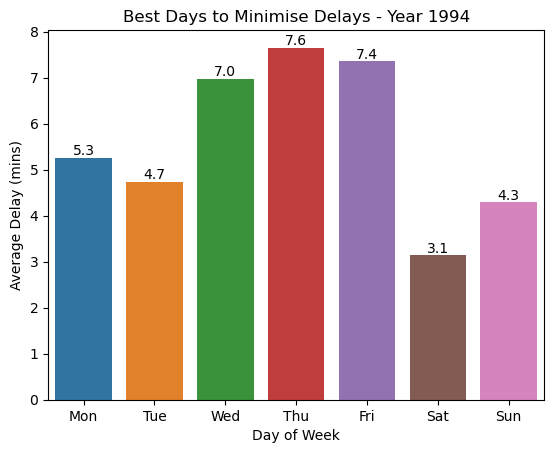

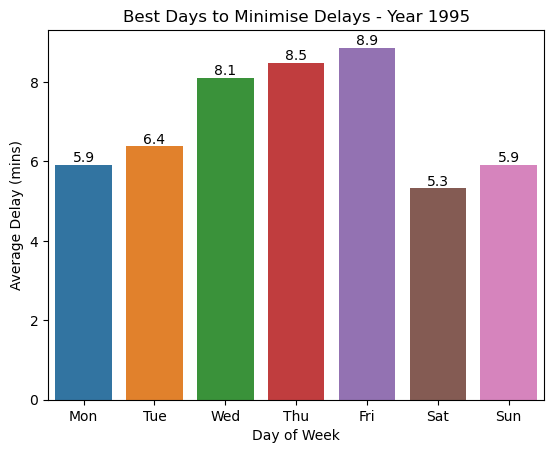

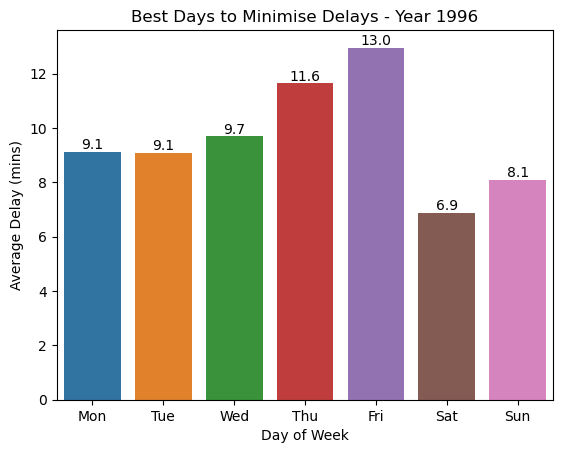

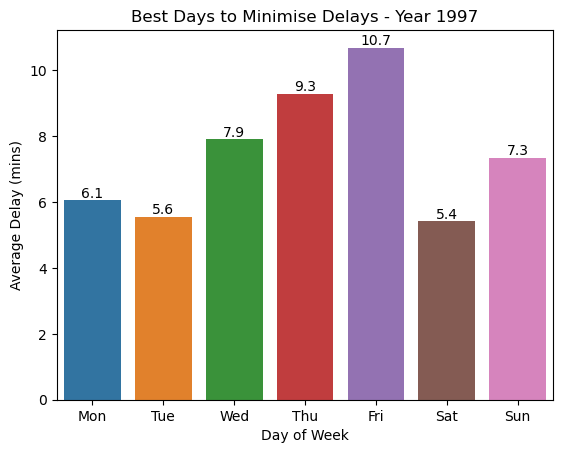

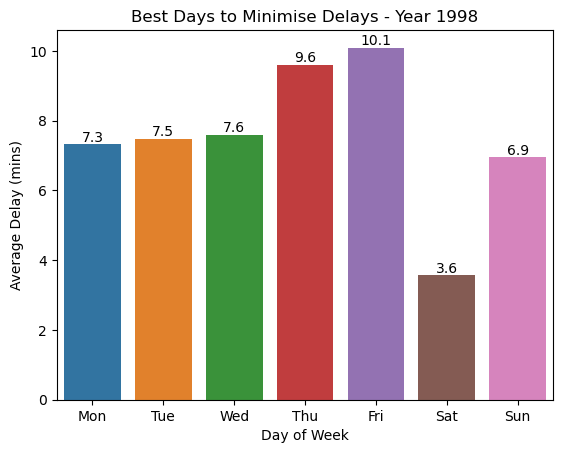

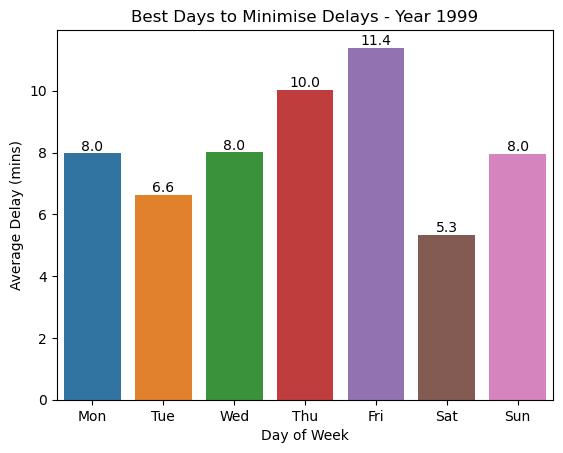

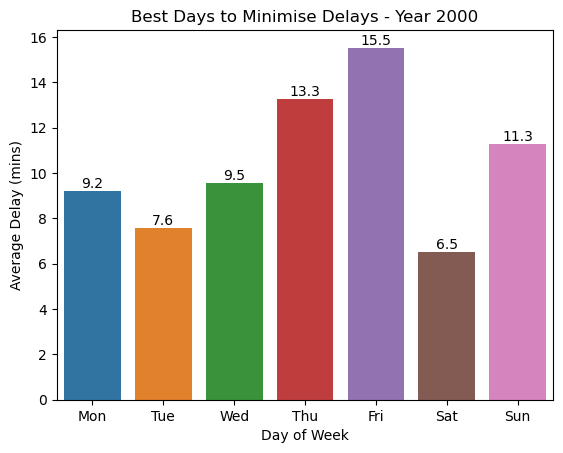

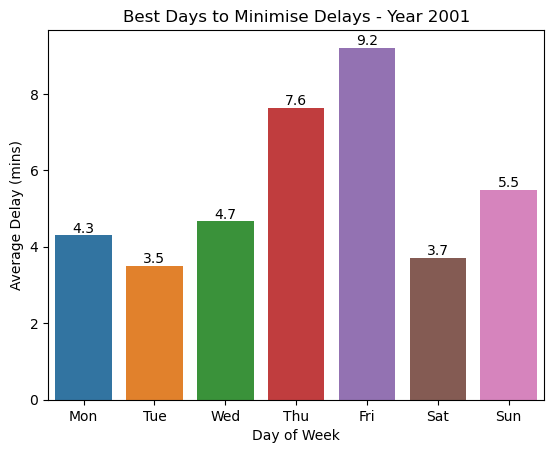

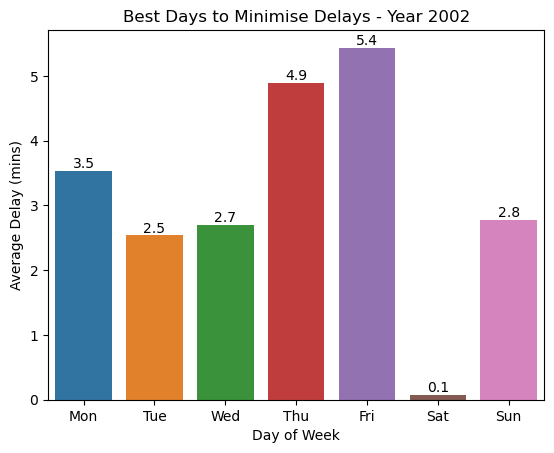

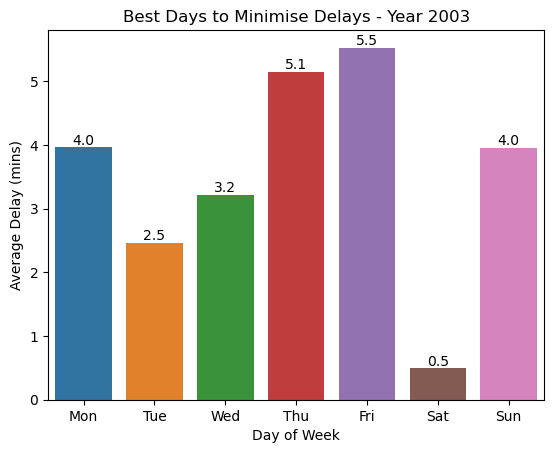

In [27]:
#Query for average arrival delay and departure delay grouped by day of week for each year

for year in range(1994, 2004):
    best_day = pd.read_sql_query(f"""
    SELECT AVG(ArrDelay) AS Avg_ArrDelay, AVG(DepDelay) AS Avg_DepDelay,
           CASE WHEN DayOfWeek = 1 THEN 'Mon'
                WHEN DayOfWeek = 2 THEN 'Tue'
                WHEN DayOfWeek = 3 THEN 'Wed'
                WHEN DayOfWeek = 4 THEN 'Thu'
                WHEN DayOfWeek = 5 THEN 'Fri'
                WHEN DayOfWeek = 6 THEN 'Sat'
                ELSE 'Sun' END AS DayOfWeek
    FROM ontime
    WHERE Cancelled = 0 AND Diverted = 0 AND Year = {year}
    GROUP BY CASE WHEN DayOfWeek = 1 THEN 'Mon'
                  WHEN DayOfWeek = 2 THEN 'Tue'
                  WHEN DayOfWeek = 3 THEN 'Wed'
                  WHEN DayOfWeek = 4 THEN 'Thu'
                  WHEN DayOfWeek = 5 THEN 'Fri'
                  WHEN DayOfWeek = 6 THEN 'Sat'
                  ELSE 'Sun' END
    ORDER BY DayOfWeek
    """, conn)

    #Reorder categories
    
    day_of_week_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
    
    #Data visualisation
    
    sns.barplot(x='DayOfWeek', y='Avg_ArrDelay', data=best_day, order=day_of_week_order)
    plt.title(f'Best Days to Minimise Delays - Year {year}')
    plt.xlabel('Day of Week')
    plt.ylabel('Average Delay (mins)')
    
    #Add value labels
    
    ax = plt.gca()
    for p in ax.patches:
        ax.text(p.get_x() + p.get_width() / 2., p.get_height(), '{:.1f}'.format(p.get_height()),
                fontsize=10, color='black', ha='center', va='bottom')
    
    #Print results
    
    plt.show()

**Analysis of results & plots above:**

In detail for each year:

In 1994, Saturday had the shortest average delay (4.7 mins).

In 1995, Saturday had the shortest average delay (5.3 mins).

In 1996, Saturday had the shortest average delay (6.9 mins).

In 1997, Saturday had the shortest average delay (5.4 mins).

In 1998, Saturday had the shortest average delay (3.6 mins).

In 1999, Saturday had the shortest average delay (5.3 mins).

In 2000, Saturday had the shortest average delay (6.5 mins).

In 2001, Tuesday had the shortest average delay (3.5 mins).

In 2002, Saturday had the shortest arrival delay (0.1 mins).

In 2003, Saturday had the shortest arrival delay (0.5 mins).

**Therefore, it can be concluded that for each year, Saturday is the best day of the week to fly to minimise delays.**

# ST2195 Coursework Part 2(b) - Python

# UOL Student Number: 220456807

# Part 2(b)

**Find the maximum and minimum manufacture years of the planes**

We execute a SQL query to find the maximum value in the "year" column of the "planes" table, using "WHERE" to filter out values that is less than 2100 which is in the future, because the lack of such limits will show a result of NA. The query is executed using "pd.read_sql_query()" function to read the results into pandas data frame "max_manufacture_year".

In [28]:
#Find maximum value in the year column

max_manufacture_year_query = """
SELECT max(year)
FROM planes
WHERE year < 2100
"""

max_manufacture_year = pd.read_sql_query(max_manufacture_year_query, conn)

#Print results

print(max_manufacture_year)

  max(year)
0      2008


We execute a SQL query to find the minimum value in the "year" column of the "planes" table, using "WHERE" to filter out values that is more than 1900 which is a very long time ago, because the lack of such limits will show a result of 0. The query is executed using "pd.read_sql_query()" function to read the results into pandas data frame "max_manufacture_year".

In [29]:
#Finding the minimum value in the year column

min_manufacture_year_query = """
SELECT min(year)
FROM planes
WHERE year > 1900
"""

min_manufacture_year = pd.read_sql_query(min_manufacture_year_query, conn)

#Print results

print(min_manufacture_year)

  min(year)
0      1946


Any plane that was manufactured later than when it was flown can be considered as erroneous data because it is not possible for a plane to be flown before it has even been manufactured.

### Check for possible erroneous data

**Possible erroneous data**

Dealing with potentially erroneous data, we assume that the “Year” column in plane-data.csv is the year the planes were manufactured. 

The “Year” column in the ontime table created refers to the year the plane was used to fly. We will be using the values in the “Year” column in the ontime table created & subtracting this value by the corresponding value in the “Year” column by matching the tail numbers of the plane to calculate the age of the plane and evaluate whether older planes suffer more delays.

We do this by executing a query to identify erroneous flight data by comparing the flight year "ontime.Year" with the manufacture year of the plane "planes.year", calculating the age of the plane at the time of the flight. Then joining the ontime table with the planes table based on the matching aircraft tail numbers "TailNum". From here, we filter the data to include only records where the calculated plane age is negative, indicating erroneous data (i.e. a flight occurring before the plane was even manufactured).

We execute a SQL query using DBI to retrieve flight information about the flight year "ontime.Year" and manufacturing years of planes "planes.year", and calculate the age of the plane during the time of flight using ("ontime.Year - plane.year" AS "Plane_Age"). This data is retrieved from the "ontime" and "planes" table, joining the two together on the condition that the tail number "TailNum" in the "ontime" table matches that of the "planes" table.

In [30]:
#Queries via DBI

erroneous_query = """
SELECT ontime.Year AS Flight_Year, planes.year AS Manufacture_Year, (ontime.Year - planes.year) AS Plane_Age
FROM ontime JOIN planes ON ontime.TailNum = planes.tailnum
WHERE (ontime.Year - planes.year) < 0
ORDER BY Plane_Age DESC
"""

erroneous = pd.read_sql_query(erroneous_query, conn)

#Print results

print(erroneous.head())

   Flight_Year Manufacture_Year  Plane_Age
0         2001             2002         -1
1         2001             2002         -1
2         2001             2002         -1
3         2001             2002         -1
4         2001             2002         -1


We execute a SQLquery using DBI to identify erroneous flight data by comparing the flight year "ontime.Year" with the manufacture year of the plane "planes.year", calculating the age of the plane at the time of the flight. Then, joining the ontime table with the planes table based on the matching aircraft tail numbers "TailNum". From here, we filter the data to include only records where the calculated plane age is greater than 57 years.

In [31]:
erroneous2_query = """
SELECT ontime.Year, planes.year, (ontime.Year - planes.year)
FROM ontime JOIN planes ON ontime.TailNum = planes.tailnum
WHERE (ontime.Year - planes.year) > 57
ORDER BY (ontime.Year - planes.year)
"""

erroneous2 = pd.read_sql_query(erroneous2_query, conn)

#Print results

print(erroneous2.head())

   Year  year  (ontime.Year - planes.year)
0  1995  None                         1995
1  1995  None                         1995
2  1995  None                         1995
3  1995  None                         1995
4  1995  None                         1995


We execute a SQL query to analyse flight delays by calculating the age of the plane at the time of the flight, and counting the total number of flights flown for each plane age.

In [32]:
#Analyse delay

analyse_delay_query = """
SELECT (ontime.Year - planes.year), COUNT(*)
FROM ontime JOIN planes ON ontime.TailNum = planes.tailnum
WHERE (ontime.Year - planes.year) > -1 AND (ontime.Year - planes.year) < 58
GROUP BY (ontime.Year - planes.year)
ORDER BY (ontime.Year - planes.year)
"""

analyse_delay = pd.read_sql_query(analyse_delay_query, conn)

analyse_delay.columns = ["Plane Age", "Total Flights"]

#Print results

print(analyse_delay.head())

   Plane Age  Total Flights
0          0         472510
1          1        1073844
2          2        1074108
3          3         981874
4          4        1035488


**Bar plot to visualise data on the distribution of the number of flights by age of plane**

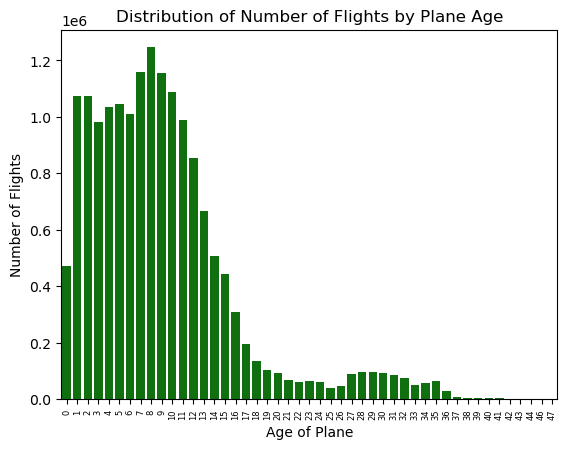

In [33]:
#Plot bar graph

sns.barplot(x = "Plane Age", y = "Total Flights", data = analyse_delay, color ='green')

plt.title("Distribution of Number of Flights by Plane Age")

plt.xlabel("Age of Plane")

plt.ylabel("Number of Flights")

plt.xticks(rotation = 90, fontsize = 6)

#Print results

plt.show()

### Analyse average arrival delay of flights by plane age

We execute a SQL query to calculate the age of the plane at the time of the flight using ("ontime.Year" - "planes.year"), average arrival delay "AVG(ArrDelay)" and count the total number of flights for each plane age, gathering the data from two tables "ontime" and "planes", joining them together based on their same aircraft taile numbers "TailNum". The results are then read into pandas data frame "average_arrival_delay".

In [34]:
#Average arrival delay

average_arrival_delay_query = """
SELECT (ontime.Year - planes.year), AVG(ArrDelay), COUNT(*)
FROM ontime JOIN planes ON ontime.TailNum = planes.tailnum
WHERE (ontime.Year - planes.year) > -1 AND (ontime.Year - planes.year) < 58
GROUP BY (ontime.Year - planes.year)
ORDER BY (ontime.Year - planes.year) ASC
"""

average_arrival_delay = pd.read_sql_query(average_arrival_delay_query, conn)

average_arrival_delay.columns = ["Plane Age", "Average Arrival Delay (mins)", "Total Flights"]

#Print results

print(average_arrival_delay.head())

   Plane Age  Average Arrival Delay (mins)  Total Flights
0          0                      5.666085         472510
1          1                      5.686679        1073844
2          2                      5.464980        1074108
3          3                      5.196651         981874
4          4                      6.347014        1035488


# Part 2(b) - Evaluate whether older planes suffer more delays on a year-to-year basis (average arrival delay)

The loop below iterates over then 10 years from 1994 to 2003, executing SQL queries to retrieve flight information on the average arrival delay of flights based on the plane age for each year, for which the results are read into a pandas data frame "year_data". Then, using seaborn "scatterplot" function, a scatter plot is generated for each year respectively with plane age on the x-axis and average arrival delay in minutes on the y-axis.

Year 1994 data:
Empty DataFrame
Columns: [Plane_Age, Avg_ArrDelay, Total_Flights]
Index: []


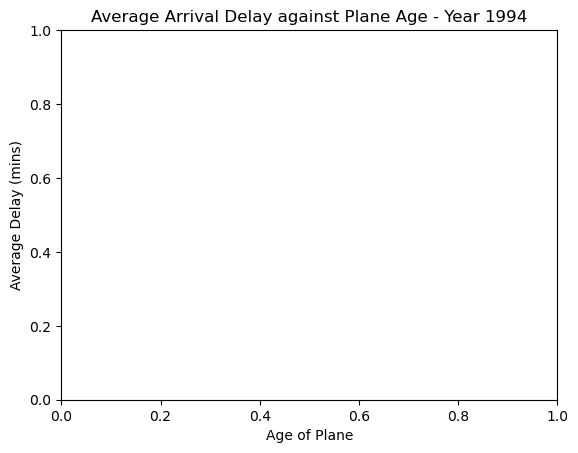

Year 1995 data:
   Plane_Age  Avg_ArrDelay  Total_Flights
0          0      7.046809          32120
1          1      5.749427          77882
2          2      6.807362          71118
3          3      6.298182         178493
4          4      7.184175         186021


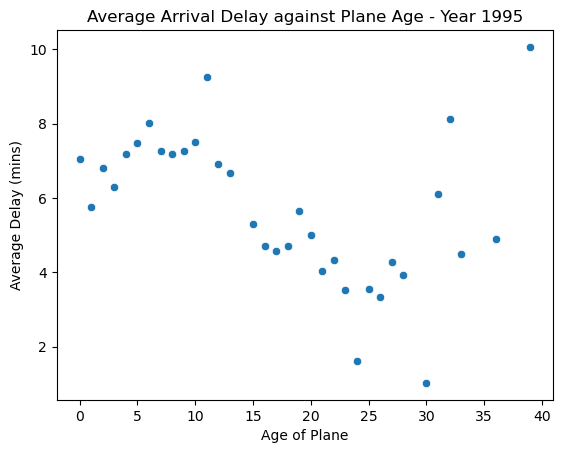

Year 1996 data:
   Plane_Age  Avg_ArrDelay  Total_Flights
0          0     11.366002          19726
1          1      9.666485          55848
2          2      9.437094          78942
3          3     10.099831          70951
4          4      9.913574         183963


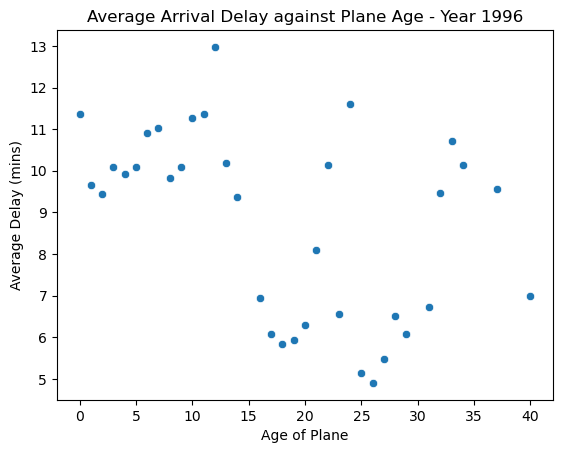

Year 1997 data:
   Plane_Age  Avg_ArrDelay  Total_Flights
0          0      6.473313          26210
1          1      7.912665          45215
2          2      7.124381          54492
3          3      6.789722          68921
4          4      8.080898          70815


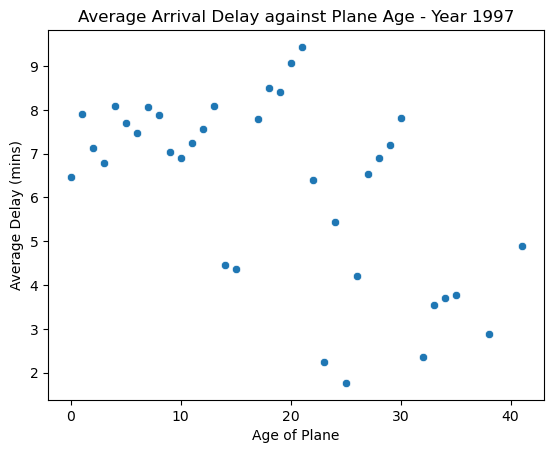

Year 1998 data:
   Plane_Age  Avg_ArrDelay  Total_Flights
0          0      6.855849          69252
1          1      7.087586          64016
2          2      8.130657          43718
3          3      6.017667          54940
4          4      7.538489          68469


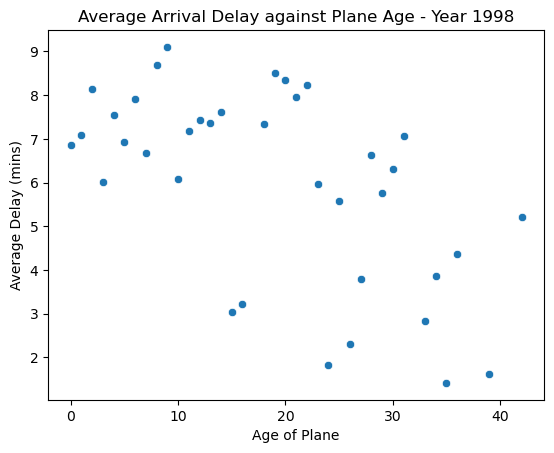

Year 1999 data:
   Plane_Age  Avg_ArrDelay  Total_Flights
0          0      6.470398          70429
1          1      7.180053         173624
2          2      7.505013          66451
3          3      6.954298          45396
4          4      6.864635          54639


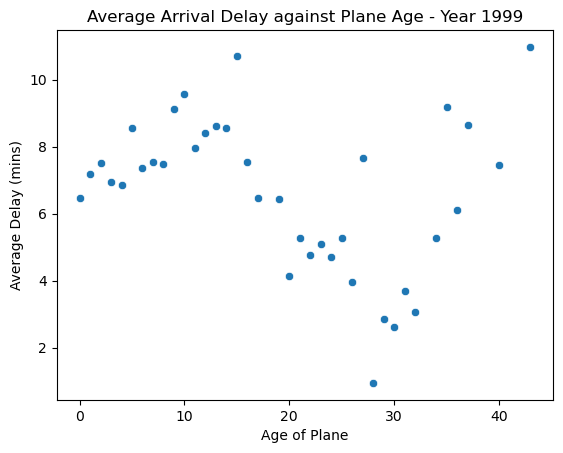

Year 2000 data:
   Plane_Age  Avg_ArrDelay  Total_Flights
0          0      8.948546          68260
1          1      8.292849         173777
2          2      9.002174         176166
3          3      9.660035          69255
4          4     12.314360          45127


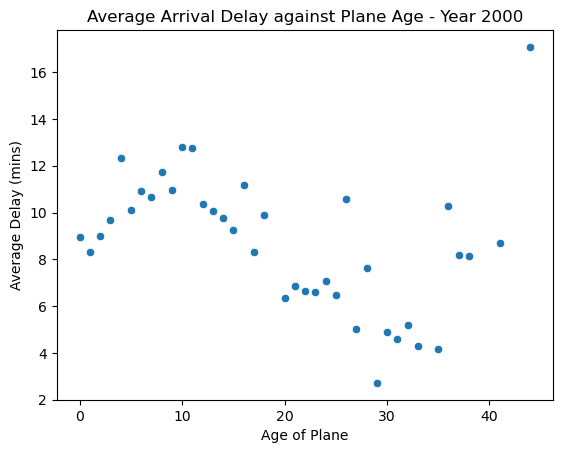

Year 2001 data:
   Plane_Age  Avg_ArrDelay  Total_Flights
0          0      4.026358           9966
1          1      2.743743          18976
2          2      1.991179          38144
3          3      1.946907          54842
4          4      2.280279          23815


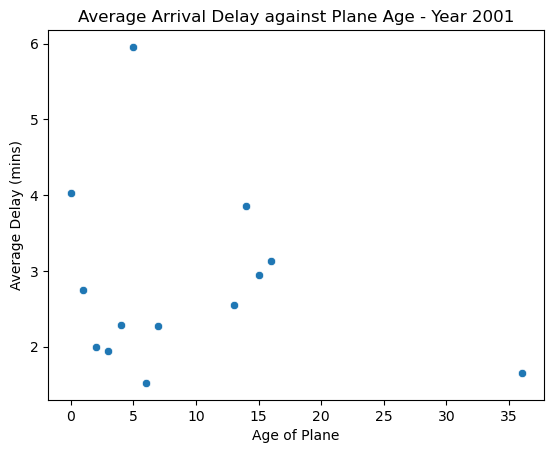

Year 2002 data:
   Plane_Age  Avg_ArrDelay  Total_Flights
0          0      1.998822          52896
1          1      2.379929         156625
2          2      1.842902         155706
3          3      2.057698         136511
4          4      2.698547         144995


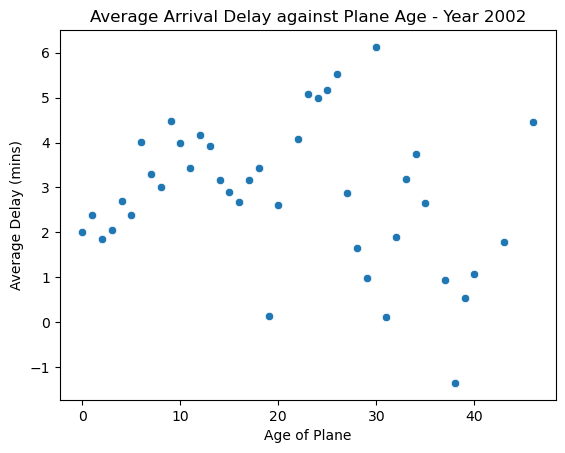

Year 2003 data:
   Plane_Age  Avg_ArrDelay  Total_Flights
0          0      3.029771         123651
1          1      3.898722         307881
2          2      3.730857         389371
3          3      3.616966         302565
4          4      3.712019         257644


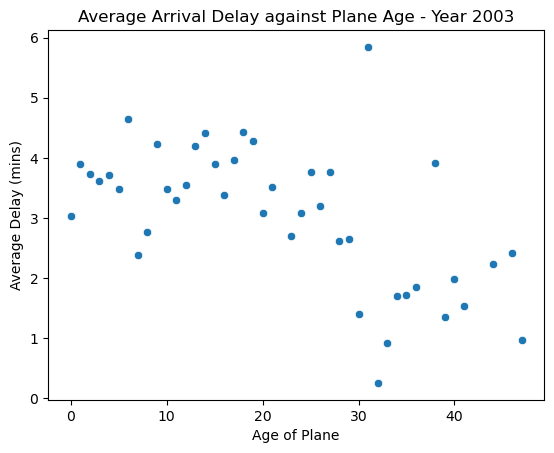

In [35]:
#Data visualisation

for year in range(1994, 2004):
    year_query = f"""
    SELECT (ontime.Year - planes.year) AS Plane_Age, AVG(ArrDelay) AS Avg_ArrDelay, COUNT(*) AS Total_Flights
    FROM ontime JOIN planes ON ontime.TailNum = planes.tailnum
    WHERE (ontime.Year - planes.year) > -1 AND (ontime.Year - planes.year) < 58 AND ontime.Year = {year}
    GROUP BY Plane_Age
    ORDER BY Plane_Age ASC
    """
    year_data = pd.read_sql_query(year_query, conn)
    
    print(f"Year {year} data:")
    
    print(year_data.head())

    #Create scatter plot for the current year
    
    plt.figure()
    
    sns.scatterplot(data=year_data, x="Plane_Age", y="Avg_ArrDelay")
    
    plt.title(f"Average Arrival Delay against Plane Age - Year {year}")
    
    plt.xlabel("Age of Plane")
    
    plt.ylabel("Average Delay (mins)")
    
    #Print results
    
    plt.show()

**Analysis of results & plots above:**

In general for the years 1994 to 2003, the dots plotted are seen to be sloping downwards, indicating that as the age of the plane increases, the average arrival delay decreases.

Based on the analysis and visualisations from above, older planes tend to suffer less delays on a year-to-year basis.

In more detail for each year:

In 1994, there is no data presented.

In 1995, plane age of 30 had the shortest average arrival delay (1.0 mins).

In 1996, plane age of 24 had the shortest average arrival delay (4.9 mins).

In 1997, plane age of 25 had the shortest average arrival delay (1.8 mins).

In 1998, plane age of 35 had the shortest average arrival delay (1.4 mins).

In 1999, plane age of 28 had the shortest average arrival delay (1.0 mins).

In 2000, plane age of 29 had the shortest average arrival delay (2.7 mins).

In 2001, plane age of 6 had the shortest average arrival delay (1.5 mins).

In 2002, plane age of 38 had the shortest average arrival delay (-1.4 mins).

In 2003, plane age of 32 had the shortest average arrival delay (0.3 mins).

Aside from year 2001, the age of plane for the shortest average arrival delay each year is of planes that are older, ie. above 24 (for our database suggests the plane age range is from 0 to 47 so: Younger = 0 to 23, Older = 24 to 47).

**Therefore, it can be concluded that for each year, older planes tend to suffer less delays.**

**Inspect data for the year 1994 for NA data**

From the queries and results above, it can be noted that we were not able to get the necessary data for the year of 1994. So we will conduct a detailed inspection to clarify if there is no data available.

In [36]:
#Query for 1994

current_query_1994 = """
SELECT (ontime.Year - planes.year) AS Plane_Age, AVG(ArrDelay) AS Avg_ArrDelay
FROM ontime JOIN planes ON ontime.TailNum = planes.tailnum
WHERE (ontime.Year - planes.year) > -1 AND (ontime.Year - planes.year) < 58
AND ontime.Year = 1994
GROUP BY (ontime.Year - planes.year)
"""

#Fetch results

year_data_1994 = pd.read_sql_query(current_query_1994, conn)

#Print results

print(year_data_1994)

#Check for NA values

print(year_data_1994.isna().sum())

#Print columns

print(year_data_1994['Plane_Age'])
print(year_data_1994['Avg_ArrDelay'])

Empty DataFrame
Columns: [Plane_Age, Avg_ArrDelay]
Index: []
Plane_Age       0.0
Avg_ArrDelay    0.0
dtype: float64
Series([], Name: Plane_Age, dtype: object)
Series([], Name: Avg_ArrDelay, dtype: object)


Upon inspection, it can be concluded that there is no data available for 1994.

### Plot general data for average arriaval delay in minutes by age of plane from 1994 to 2003

In [37]:
#Execute query for 1994 to 2003

results = conn.execute(average_arrival_delay_query)

year_data = pd.DataFrame(results.fetchall(), columns=["Plane Age", "Avg_ArrDelay", "Total Flights"])

In [38]:
#Ensure that values in plane age are numeric

year_data["Plane Age"] = pd.to_numeric(year_data["Plane Age"])

#Remove rows with NA values

year_data = year_data.dropna(subset=["Plane Age", "Avg_ArrDelay"])

#Create age intervals

age_intervals = pd.cut(year_data["Plane Age"], bins=[0, 10, 20, 30, 40, 48], labels=["0-10", "11-20", "21-30", "31-40", "41-47"])

#Add age intervals into data frame

year_data["Age Intervals"] = age_intervals

               count      mean       std       min       25%       50%  \
Age Intervals                                                            
0-10            10.0  6.965304  1.209933  5.196651  5.851762  7.214928   
11-20           10.0  5.776340  1.094737  4.391307  5.024833  5.583866   
21-30           10.0  5.434877  0.918940  4.258445  4.844932  5.311856   
31-40           10.0  3.819760  1.608346  1.566323  2.881293  3.716011   
41-47            6.0  3.533568  1.859805  0.969412  2.638239  3.179569   

                    75%       max  
Age Intervals                      
0-10           8.021004  8.432579  
11-20          6.640027  7.544191  
21-30          5.957758  7.295292  
31-40          4.376887  7.380315  
41-47          4.802497  6.071588  


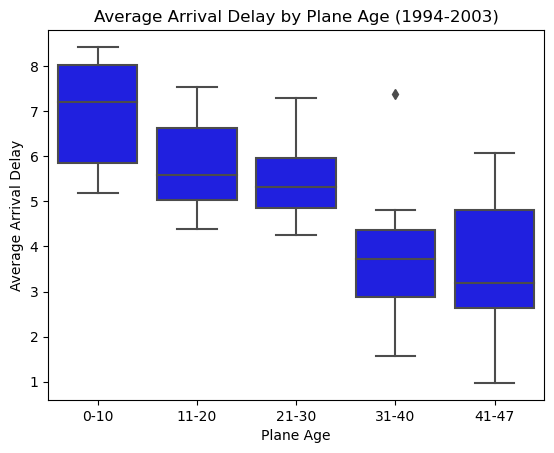

In [39]:
#Create a boxplot for 1994 to 2003

plt.figure()

sns.boxplot(data=year_data, x = "Age Intervals", y = "Avg_ArrDelay", color = 'blue')

plt.title("Average Arrival Delay by Plane Age (1994-2003)")

plt.xlabel("Plane Age")

plt.ylabel("Average Arrival Delay")

#Print values

summary_table = year_data.groupby("Age Intervals")["Avg_ArrDelay"].describe()
print(summary_table)

#Print results

plt.show()

**Analysis of results & plots above**

For the 0-10 plane age interval, the average arrival delay has a mean of 7.0 minutes, with the standard deviation at 1.2 minutes. There is no evident outliers in this plane age interval.

For the 11-20 plane age interval, the average arrival delay has a mean of 5.8 minutes, with the standard deviation at 1.1 minutes. There is no evident outliers in this plane age interval.

For the 21-30 plane age interval, the average arrival delay has a mean of 5.4 minutes, with the standard deviation at 0.9 minutes, indicating less variability in the data. The interquartile range is relatively narrower. There is no evident outliers in this plane age interval.

For the 31-40 plane age interval, the average arrival delay has a mean of 3.8 minutes, with the standard deviation at 1.6 minutes. There is an evident outlier in this plane age interval, at about 7 minutes.

For the 41-47 plane age interval, the average arrival delay has a mean of 3.5 minutes, with the standard deviation at 1.9 minutes, indicating more variability in the data. There is no evident outliers in this plane age interval.

Thus, the average arrival delay is the shortest for planes of ages ranging from 31 to 40. The average arrival delay is generally longer for planes of ages ranging from 0 to 30 as compared to planes of ages from 31-47. There is a longer delay for younger planes.

**Overall, it can be concluded that for years 1994 to 2003, older planes suffer less delay.**

# ST2195 Coursework Part 2 (c) - Python

# UOL Student Number: 220456807

# Part 2(c)

Import the necessary and essential packages for our data analysis to do data pre-processing, model building, evaluation and visualisation in machine learning.

The "numpy" library provides support for mathematical functions and operations on arrays.

The "sklearn" package is to help us with data pre-processing, model selection, learning models, metrics, evaluation and pipeline.

In [40]:
#Import necessary packages

import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.linear_model import LogisticRegression

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler, MinMaxScaler

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, classification_report

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier

from sklearn.experimental import enable_hist_gradient_boosting

/Users/joline/anaconda3/lib/python3.11/site-packages/sklearn/experimental/enable_hist_gradient_boosting.py:15: UserWarning: Since version 1.0, it is not needed to import enable_hist_gradient_boosting anymore. HistGradientBoostingClassifier and HistGradientBoostingRegressor are now stable and can be normally imported from sklearn.ensemble.
  warnings.warn(


**Query to retrieve necessary information for building logistic regression model**

We execute the SQL query to select the required features, age of plane, diverted and distance from the "ontime" and "planes" tables to builda model to preduct departure delay.

In [41]:
#Query for plane age, diverted flights and distance information

query = """
    SELECT DepDelay, (ontime.Year - planes.year) AS AgeofPlane, Diverted, Distance
    FROM ontime JOIN planes ON ontime.TailNum = planes.tailnum
    WHERE Cancelled = 0 AND  (ontime.Year - planes.year) >= 0 AND (ontime.Year - planes.year) < 58
"""

Then we execute the SQL query stored in the "query" variable using "pd.read_sql_query()" from pandas, to load the result of the query into data frame "flight_data".

In [42]:
#Execute query and load the data into a data frame

flight_data = pd.read_sql_query(query, conn)

We want to split the flight data into training and test datasets respectively for machine learning modelling. After running the codes below, we will have four datasets: "X_train" which has the features for training the model, "y_train" for target variables corresponding to the training data, "X_test" for features for evaluating the model's performance and "y_test" for target varaibles corresponding to the test data.

In [43]:
#Split into training and test datasets

X = flight_data.drop(columns=['Diverted'])  #Feature (X)
y = flight_data['Diverted']  #Target variable (y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

The preprocessing pipeline is defined as "preprocessor", "sklearn.pipeline.Pipeline" and "sklearn.compose.ColumnTransformer" can be used within a large pipeline to pre-process the data prior to model training. This handles the missing values and standardises numerical features, ensuring that the data is prepared for modeling, using "SimpleImputer" to impute missing values and "StandardScaler" to standardise numerical features.

In [44]:
#Pipeline: pre-processing

numerical_features = ["DepDelay", "AgeofPlane", "Distance"]

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),  #Impute missing values with mean
    ('scaler', StandardScaler())  #Standardise numerical features
])

preprocessor = ColumnTransformer(
    transformers=[
        ('numerical', numerical_transformer, numerical_features)
    ]
)

In [45]:
#Set parameters for hyperparameter tuning

param_grid = {
    'preprocessor__numerical__imputer__strategy': ['mean', 'median', 'most_frequent']
}

We create a machine learning pipeline "log_reg_mode" for logistic regression model using "pipeline" from "sklearn.pipeline", to combine the data pre-processing and model training into a single object so that the input data is prepared before being trianed in the logistic regression models.

In [46]:
#Create a logistic regression mpdel

log_reg_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

In [47]:
#Grid search for hyperparameter tuning

grid_search = GridSearchCV(log_reg_model, param_grid, cv=5)
grid_search.fit(X_train, y_train)

#Print model evaluation

print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

Best parameters: {'preprocessor__numerical__imputer__strategy': 'mean'}
Best score: 0.9978206340896898


We extract the coefficients of the logistic regression model from the best estimator obtained through grid search, "grid_search.best_estimator_" to return the best fitted model, and "named_steps{'classifier']" to access the logistic regression classifier within the pipeline. Then, we create a bar plot using seaborn "sns.barplot" to visualise the coefficients of the logistc regresision model.

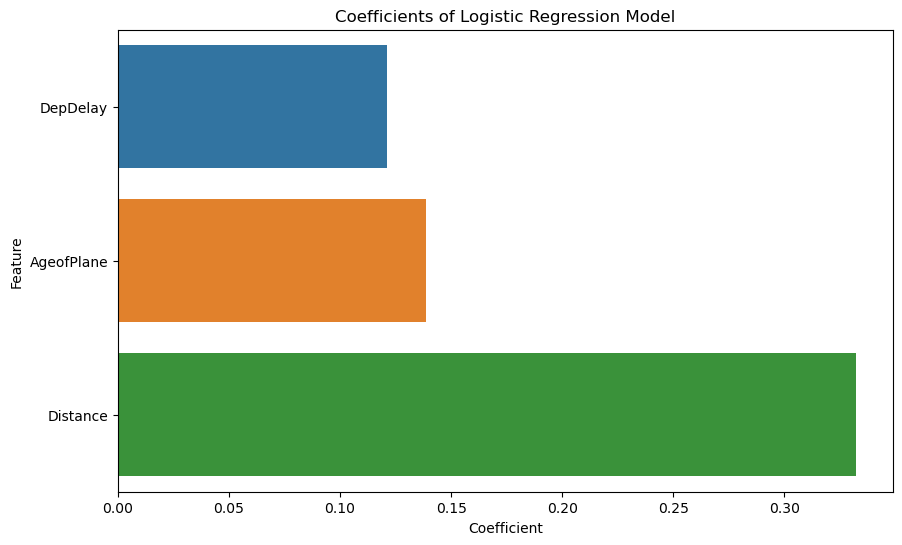

In [48]:
#Visualisation of coefficients: DepDelay, AgeofPlane and Distance

coefficients = grid_search.best_estimator_.named_steps['classifier'].coef_

features = numerical_features
plt.figure(figsize=(10, 6))
sns.barplot(x=coefficients.ravel(), y=features)
plt.title('Coefficients of Logistic Regression Model')
plt.xlabel('Coefficient')
plt.ylabel('Feature')

plt.show()

The provided output indicates that the logistic regression model achieved a very high accuracy (best score of approximately 99.78%) using the selected parameters. This suggests that the model fits the training data very well and can predict flight diversions with high accuracy.

The bar plot with coefficients for only three features, DepDelay, AgeofPlane and Distance. The coefficients indicate the strength and direction of the relationship between each feature and the probability of flight diversion.

Here is the analysis for the results above:

DepDelay: The positive coefficient suggests that an increase in departure delay (DepDelay) is associated with a high probability of flight diversion.

AgeofPlane: The positive coefficient suggests that older planes (higher AgeofPlane) are associated with a higher probability of flight diversion.

Distance: The positive coefficient suggests that further distance (Distance) is associated with a higher probability of flight diversion.

**Correlation Heatmap**

Correlation coefficients lies in the range from -1 to 1, where: Values close to 1 indicate a strong positive correlation, values close to -1 indicate a strong negative correlation and values close to 0 indicate little to no linear relationship between the features.

The printed correlation matrix below help us to understand the relationships between different numerical features in the flight data. In this specific case, it shows the correlation coefficients between departure delay (DepDelay), age of the plane (AgeofPlane), diversion status (Diverted), and distance (Distance).

In [49]:
#Correlation matrix

print("\nCorrelation matrix:")

numerical_flight_data = flight_data.select_dtypes(include=np.number)

print(numerical_flight_data.corr())


Correlation matrix:
            DepDelay  AgeofPlane  Diverted  Distance
DepDelay    1.000000   -0.011270  0.029587  0.015295
AgeofPlane -0.011270    1.000000  0.003517 -0.148109
Diverted    0.029587    0.003517  1.000000  0.016612
Distance    0.015295   -0.148109  0.016612  1.000000


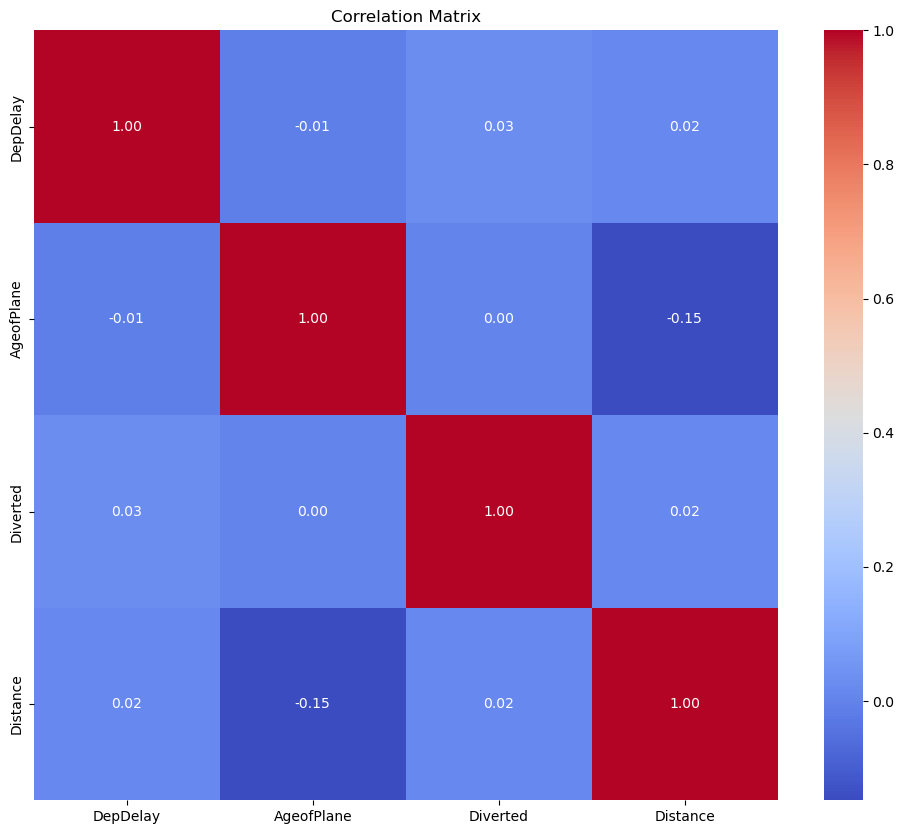

In [50]:
correlation_matrix = numerical_flight_data.corr()

# Check the lengths of coefficients and features

if len(correlation_matrix.columns) == len(correlation_matrix):
    
    # If lengths match, plot the correlation matrix
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlation Matrix')
    plt.show()
    
else:
    print("Lengths of coefficients and features do not match. Unable to plot.")
    
    # You can also identify the mismatched features
    
    print("Number of coefficients:", len(correlation_matrix.columns))
    print("Number of features:", len(correlation_matrix))

**Main findings from the correlation matrix and results above:**

There is a weak and negative correlation between departure delay and the age of the plane as shown by the correlation coefficient of -0.011. Thus, there is a probability for older planes to have shorter departure delays.

There is a weak and positive correlation between departure delay and the diversion status of a flight as shown by the correlation coefficient of 0.030. Thus, there is a probability for flights with longer departure delays to be diverted.

There is a weak and positive correlation between departure delay and the flight distance as shown by the correlation coefficient of 0.015. Thus, there is a probability for flights with longer distance to experience longer departure delays.

There is a weak and positive correlation between the age of the plane and the diversion status of a flight as shown by the correlation coefficient of 0.004. Thus, there is a very minimal probability for the age of a plane to affect flight diversion.

There is a weak and negative correlation between the age of the plane and the flight distance as shown by the correlation coefficient of -0.148. Thus, there is a probability for older planes to have shorter distances.

There is a weak and positive correlation between the diversion status of a flight and the flight distance as shown by the correlation matric of 0.017. Thus, there is a probability for longer distance flights to be diverted.

# Part 2(c) - Fitting logistic regression model

We define the function "fetch_and_preprocess_data" to retrieve and pre-process required flight data for each year from the data base and "ontime" table, and return it in a data frame format "data_year".

In [51]:
#Define function to fetch and preprocess data

def fetch_and_preprocess_data(year):
    query = f"""
        SELECT Year, Month, DayofMonth, DayOfWeek, Distance, CRSDepTime, CRSArrTime, Diverted
        FROM ontime WHERE Year = {year}
    """
    
    # Fetch data
    
    data_year = pd.read_sql_query(query, conn)
    return data_year

Create an empty dictionary "models" to store the necessary data for each year.

In [52]:
models = {}

We iterate the codes over then 10 years from 1994 to 2003 and fetch and pre-process data for each year using "fetch_and_preprocess_data()".

Later, we store the fitted logistic regression mode "model_year" in the "models" dictionary with the year as the key.

In [53]:
#Loop for each year from 1994 to 2003

for year in range(1994, 2004):
    
    #Fetch and pre-process data
    
    data_year = fetch_and_preprocess_data(year)
    
    #Impute missing values
    
    imputer = SimpleImputer(strategy='mean')
    X_imputed = imputer.fit_transform(data_year.drop(columns=['Diverted', 'Year']))
    
    #Fit logistic regression model
    
    X = data_year.drop(columns=['Diverted', 'Year'])
    y = data_year['Diverted']
    model_year = LogisticRegression(max_iter=1000).fit(X_imputed, y)
    
    #Store fitted model
    
    models[str(year)] = model_year

We initialise an empty data frame "coefficients_df" to store the coefficients of the logistic regression models over the 10 years from 1994 to 2003. This is for easier visualisation and analysis for coefficients over time.

In [54]:
#Initialise data frame to store coefficients

coefficients_df = pd.DataFrame(columns=['Year', 'Feature', 'Coefficient'])

In the loop below that iterates over the 10 years from 1994 to 2003, the "coefficients_df" data frame will contain coefficients of each feature (month, day of month, day of week, distance, CRSDep time nd CRSArr time.

In [55]:
#Loop for each year from 1994 to 2003

for year in range(1994, 2004):
    
    #Retrieve coefficients
    
    coefficients = models[str(year)].coef_[0]
    
    #Remove not needed features
    
    features = data_year.columns.drop(['Diverted', 'Year'])
    
    #Create data frame
    
    year_df = pd.DataFrame({
        'Year': np.repeat(year, len(features)),
        'Feature': features,
        'Coefficient': coefficients
    })
    
    #Append 'year_df' to 'coefficients_df'
    
    coefficients_df = pd.concat([coefficients_df, year_df], ignore_index=True)

# Part 2(c) - Visualise coefficients from 1994 to 2003

We are using a line plot using seaborn's "lineplot" function to visualise how the coefficients of the various features (month, day of month, day of week, distance, scheduled departure time and scheduled arrival time) in logistic regression models vary from 1994 to 2003, providing insights about how the relationships between these features and the probability of flight is delayed over time.

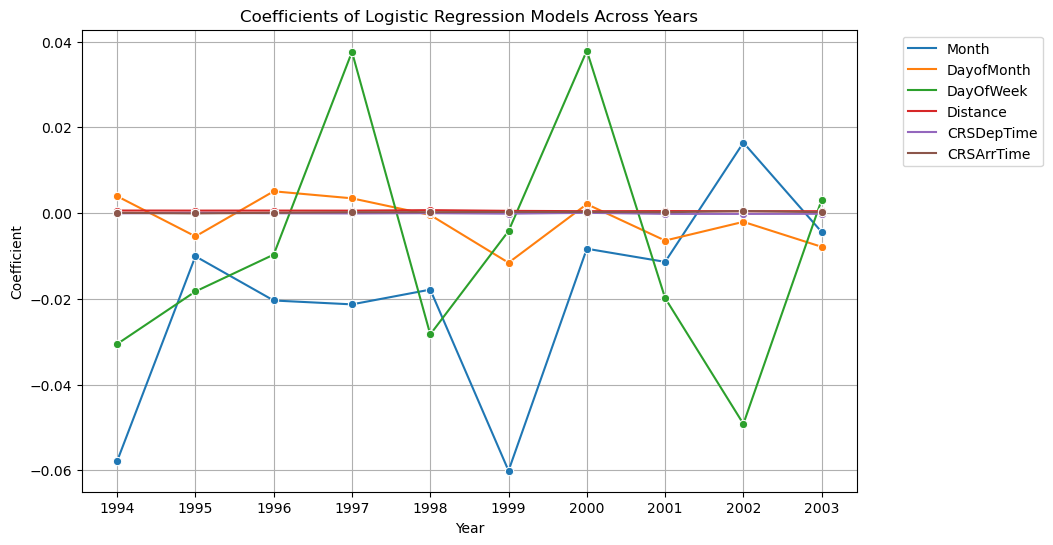

In [56]:
#Visualise coefficients from 1994 to 2003

plt.figure(figsize=(10, 6))

sns.lineplot(data=coefficients_df, x='Year', y='Coefficient', hue='Feature', marker='o')

plt.title('Coefficients of Logistic Regression Models Across Years')
plt.xlabel('Year')
plt.ylabel('Coefficient')
plt.xticks(range(1994, 2004))

plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

In [57]:
#Calculate mean coefficient for each year and feature respectively

results_table = coefficients_df.groupby(['Year', 'Feature'])['Coefficient'].mean().reset_index()

#Print results

print(results_table)

    Year     Feature  Coefficient
0   1994  CRSArrTime     0.000055
1   1994  CRSDepTime    -0.000047
2   1994   DayOfWeek    -0.030532
3   1994  DayofMonth     0.003940
4   1994    Distance     0.000602
5   1994       Month    -0.057843
6   1995  CRSArrTime    -0.000063
7   1995  CRSDepTime     0.000066
8   1995   DayOfWeek    -0.018278
9   1995  DayofMonth    -0.005430
10  1995    Distance     0.000583
11  1995       Month    -0.010073
12  1996  CRSArrTime     0.000066
13  1996  CRSDepTime    -0.000031
14  1996   DayOfWeek    -0.009681
15  1996  DayofMonth     0.005084
16  1996    Distance     0.000589
17  1996       Month    -0.020381
18  1997  CRSArrTime     0.000206
19  1997  CRSDepTime    -0.000073
20  1997   DayOfWeek     0.037598
21  1997  DayofMonth     0.003448
22  1997    Distance     0.000575
23  1997       Month    -0.021285
24  1998  CRSArrTime     0.000218
25  1998  CRSDepTime    -0.000013
26  1998   DayOfWeek    -0.028290
27  1998  DayofMonth    -0.000444
28  1998    Di

**Analysis of results & plots above:**

In general for the years 1994 to 2003, the "day of week", "day of month" and "month" features have a stronger association with a flight being diverted as the magnitude of coefficients is generally greater, as compared to "scheduled arrival time", "scheduled departure time" and "distance" which have generally weaker association because of the smaller general magnitude of coefficients. The coefficients' varying from 1994 to 2003 suggests that potential changes in the factors influencing flight diversion over time. Analysing these trends can help identify patterns and factors of diverted flights within the US aviation industry. The factors influencing flight diversion are multifaceted and may include a combination of operational, environmental, regulatory, and technological variables. Further research is necessary to accurately address the probability of diverted flights in the aviation sector.

**In more detail for each year:**

In 1994, "Month" has the greatest positive coefficient (0.0578), indicating that the month has the strongest influence on the likelihood of a flight being diverted, while "CRSDepTime" has the weakest negative coefficient (-0.000045), indicating a very minor influence on flight diversion.

In 1995, "DayOfWeek" has the greatest negative coefficient (-0.018), suggesting that the day of the week has the strongest influence on flight diversion, while "CRSArrTime" has the weakest negative coefficient (-0.000063), indicating a minor influence on flight diversion.

In 1996, "CRSArrTime" has the greatest positive coefficient (0.000066), suggesting that the scheduled arrival time has the strongest influence on flight diversion, while "CRSDepTime" has the weakest negative coefficient (-0.000031), indicating a minor influence on flight diversion.

In 1997, "DayOfWeek" has the greatest positive coefficient (0.038), suggesting that the day of the week has the strongest influence on flight diversion, while "CRSDepTime" has the weakest negative coefficient (-0.000073), indicating a minor influence on flight diversion.

In 1998, "CRSArrTime" has the greatest positive coefficient (0.000218), suggesting that the scheduled arrival time has the strongest influence on flight diversion, while "DayofMonth" has the weakest negative coefficient (-0.000439), indicating a minor influence on flight diversion.

In 1999, "CRSArrTime" has the greatest positive coefficient (0.000272), suggesting that the scheduled arrival time has the strongest influence on flight diversion, while "CRSDepTime" has the weakest negative coefficient (-0.000130), indicating a minor influence on flight diversion.

In 2000, "DayOfWeek" has the greatest positive coefficient (0.038), suggesting that the day of the week has the strongest influence on flight diversion, while "DayofMonth" has the weakest negative coefficient (-0.000020), indicating a minor influence on flight diversion.

In 2001, "CRSArrTime" has the greatest positive coefficient (0.000206), suggesting that the scheduled arrival time has the strongest influence on flight diversion, while "CRSDepTime" has the weakest negative coefficient (-0.000175), indicating a minor influence on flight diversion.

In 2002, "CRSArrTime" has the greatest positive coefficient (0.000478), suggesting that the scheduled arrival time has the strongest influence on flight diversion, while "DayofMonth" has the weakest negative coefficient (-0.000020), indicating a minor influence on flight diversion.

In 2003, "CRSArrTime" has the greatest positive coefficient (0.000224), suggesting that the scheduled arrival time has the strongest influence on flight diversion, while "CRSDepTime" has the weakest negative coefficient (-0.000163), indicating a minor influence on flight diversion.

**In more detail for each feature:**

For "CRSArrTime", the most affected year was 2002 with a coefficient of 0.000478 while 1995 was the least affected year with a coefficient of -0.000063. There are generally positive coefficients which suggest that the scheduled arrival time has a positive association with flight diversion from 1994 to 2003.

For "CRSDepTime", the most affected year was 2000 with a coefficient of 0.000065 while 1994 was the least affected year with a coefficient of -0.000045. Generally, there are mixed coefficients with some years showing positive associations and some showing negative associations with flight diversion from 1994 to 2003.

Both departure and arrival times have minimal effects on flight diversion probability, with coefficients close to zero from 1994 to 2003. Both CRSDepTime and CRSArrTime had minimal influence on the probability of flight diversion, as shown by coefficients close to zero from 1994 to 2003. This suggests that the scheduled departure and arrival times alone may not significantly affect the probability of diverted flights.


For "DayOfWeek", the most affected year was 2000 with a coefficient of 0.038 while 1994 was the least affected year with a coefficient of -0.0305. There are generally positive coefficients which suggest that the day of the week has a positive association with flight diversion from 1994 to 2003.

The day of the week has varying effects on flight diversion. Negative coefficients suggest a decrease in diversion probability for certain days compared to others. The results shows a consistent trend where certain days of the week exhibit a higher likelihood of flight diversion compared to others. For instance, negative coefficients for some years indicate a lower probability of diversion on specific weekdays. This suggests that operational factors or external conditions on these days may contribute to a reduced chance of diverted flights.


For "DayofMonth", the most affected year was 1994 with a coefficient of 0.004 while 1998 was the least affected year with a coefficient of -0.000439. Generally, there are mixed coefficients with some years showing positive associations and some showing negative associations with flight diversion from 1994 to 2003.

There is a slight variability in the effect of the day of the month on flight diversion, with coefficients close to zero. The impact of the day of the month on flight diversion appears to be minimal, as indicated by coefficients close to zero from 1994 to 2003. 


For "Month", the most affected year was 1994 with a coefficient of -0.0578 while 2000 was the least affected year with a coefficient of -0.008312. There are generally negative coefficients which suggest that the month has a negative association with flight diversion from 1994 to 2003. 

The month of the year has some variability in its impact on flight diversion. Negative coefficients indicate smaller probability of diverted flights in certain months, which suggest a less likelihood of diversion. The effect of the month on flight diversion probability varies from 1994 to 2003. This could be due to seasonal factors, weather patterns.


For "Distance", the most affected year was 1997 with a coefficient of 0.000575 while 2001 was the least affected year with a coefficient of 0.000472. There are generally positive coefficients which suggest that distance has a positive association with flight diversion from 1994 to 2003. 

Distance shows a consistent positive effect on flight diversion probability, indicating that longer flights are more likely to be diverted. The positive coefficients associated with distance indicate that longer flights are more prone to diversion. This aligns with expectations, as longer flights involve greater operational complexities and potential for disruptions, such as adverse weather conditions, which may necessitate diversion to alternate airports.

After gathering the relevant data, we close the connection to the SQLite database.

In [58]:
# Disconnect from database

conn.close()